C:\Users\10856\Desktop\GithubProject\MADRL_ESS\utils\records.py:392: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=[], labels=[], loc="upper right")


,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Global MISOCP,continuous,859.493490,1463.986860,604.493371,-604.493371,0.0,-604.493370,0.744521,0.000089,...,0.018671,0.057787,0.005165,0.039621,0,97.855133,29.268574,293.777328,42.766031,-604.493370
1,Local MPC + Perfect Forecast,continuous,900.239625,1476.654497,576.414872,-576.414872,0.0,-576.414875,7.804380,0.000077,...,0.019089,0.065087,0.005663,0.039240,157,170.051788,33.020977,312.749985,44.195540,-576.414875
2,Local MPC + LSTM Forecast,continuous,420.675320,685.847120,265.171800,-265.171800,0.0,-265.171797,4.058020,0.000355,...,0.016133,0.048325,0.004974,0.039240,106,170.441498,27.643175,200.148422,27.429650,-265.171797
3,ADMM MPC + LSTM Forecast,continuous,359.990929,548.675096,188.684167,-188.684167,0.0,-188.684170,4.954474,0.000004,...,0.011114,0.049438,0.004340,0.039605,0,99.370369,21.769003,115.623674,23.773235,-188.684170
4,MADRL + No Safety + LSTM Forecast,continuous,990.884770,1262.283105,271.398335,-271.398335,0.0,-271.398335,17.732010,0.000000,...,0.018710,0.058127,0.008448,0.040507,38,138.274078,34.542976,187.423204,43.299904,-271.398335
5,MADRL + Safety Penalty + LSTM Forecast,continuous,978.592929,980.056539,1.463610,-1.463610,0.0,-1.463614,15.924883,0.074388,...,0.014271,0.065317,0.008832,0.054602,13,149.064316,27.413601,178.712097,34.441770,-1.463614
6,MADRL + Safety Projection + LSTM Forecast,continuous,776.605519,1051.104011,274.498492,-274.498492,0.0,-274.498490,21.055009,0.000000,...,0.013260,0.049507,0.007071,0.039658,6,113.217110,25.272695,168.870705,34.871191,-274.498490


,controller,storage_discharge_revenue_total_eur,storage_charge_cost_total_eur,storage_profit_total_eur
0,Global MISOCP,1463.986860,859.493490,604.493371
1,Local MPC + Perfect Forecast,1476.654497,900.239625,576.414872
2,Local MPC + LSTM Forecast,685.847120,420.675320,265.171800
3,ADMM MPC + LSTM Forecast,548.675096,359.990929,188.684167
4,MADRL + No Safety + LSTM Forecast,1262.283105,990.884770,271.398335
5,MADRL + Safety Penalty + LSTM Forecast,980.056539,978.592929,1.463610
6,MADRL + Safety Projection + LSTM Forecast,1051.104011,776.605519,274.498492


,controller,voltage_violation_steps,voltage_violation_bus_points,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw
0,Global MISOCP,24,24,0.018671,0.057787,0.005165,0.039621,0,97.855133,29.268574,293.777328
1,Local MPC + Perfect Forecast,24,24,0.019089,0.065087,0.005663,0.039240,157,170.051788,33.020977,312.749985
2,Local MPC + LSTM Forecast,20,20,0.016133,0.048325,0.004974,0.039240,106,170.441498,27.643175,200.148422
3,ADMM MPC + LSTM Forecast,1,1,0.011114,0.049438,0.004340,0.039605,0,99.370369,21.769003,115.623674
4,MADRL + No Safety + LSTM Forecast,5,5,0.018710,0.058127,0.008448,0.040507,38,138.274078,34.542976,187.423204
5,MADRL + Safety Penalty + LSTM Forecast,1,1,0.014271,0.065317,0.008832,0.054602,13,149.064316,27.413601,178.712097
6,MADRL + Safety Projection + LSTM Forecast,0,0,0.013260,0.049507,0.007071,0.039658,6,113.217110,25.272695,168.870705


1. 电价


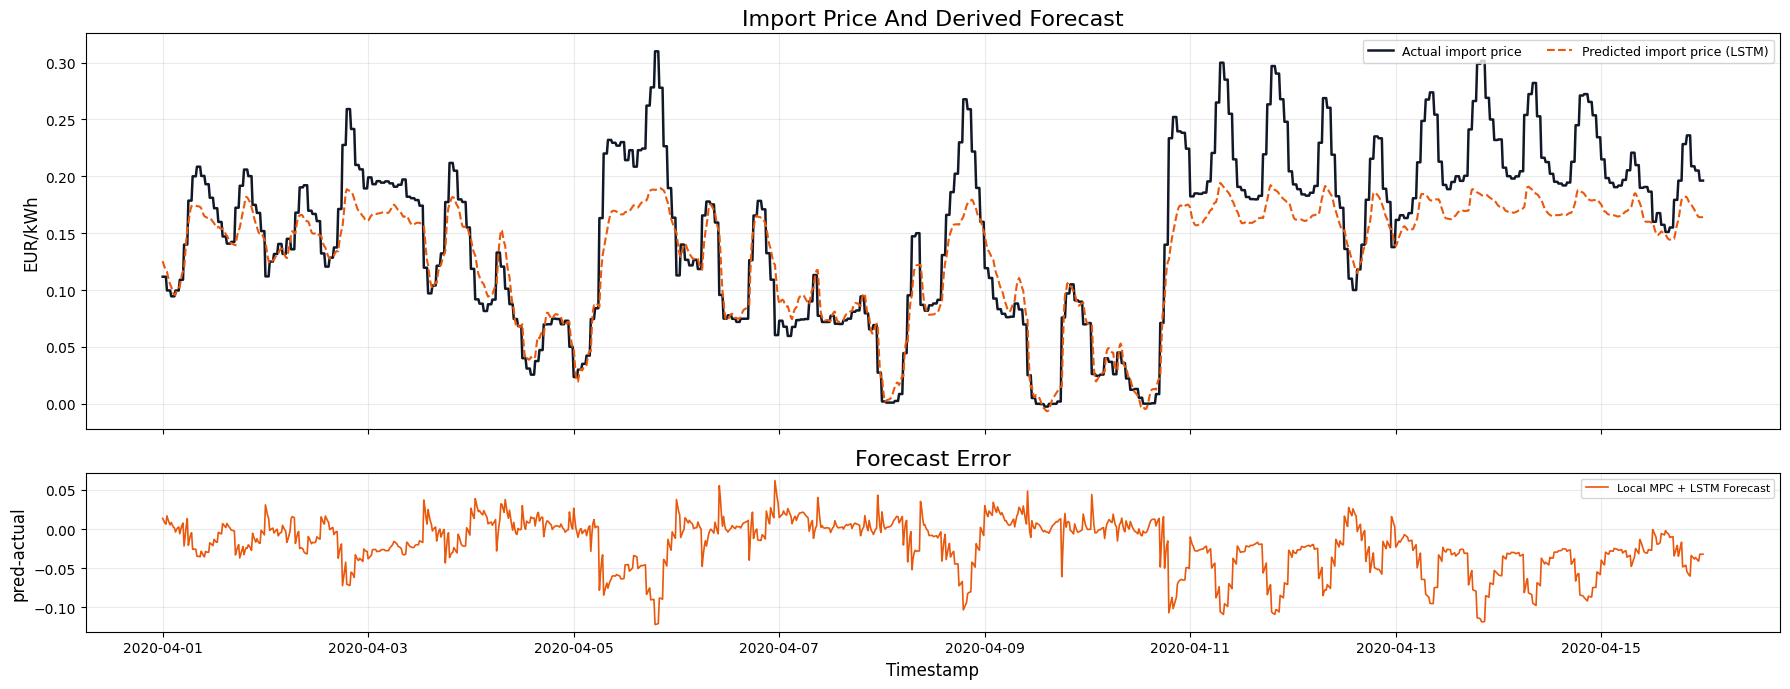

2. 电压


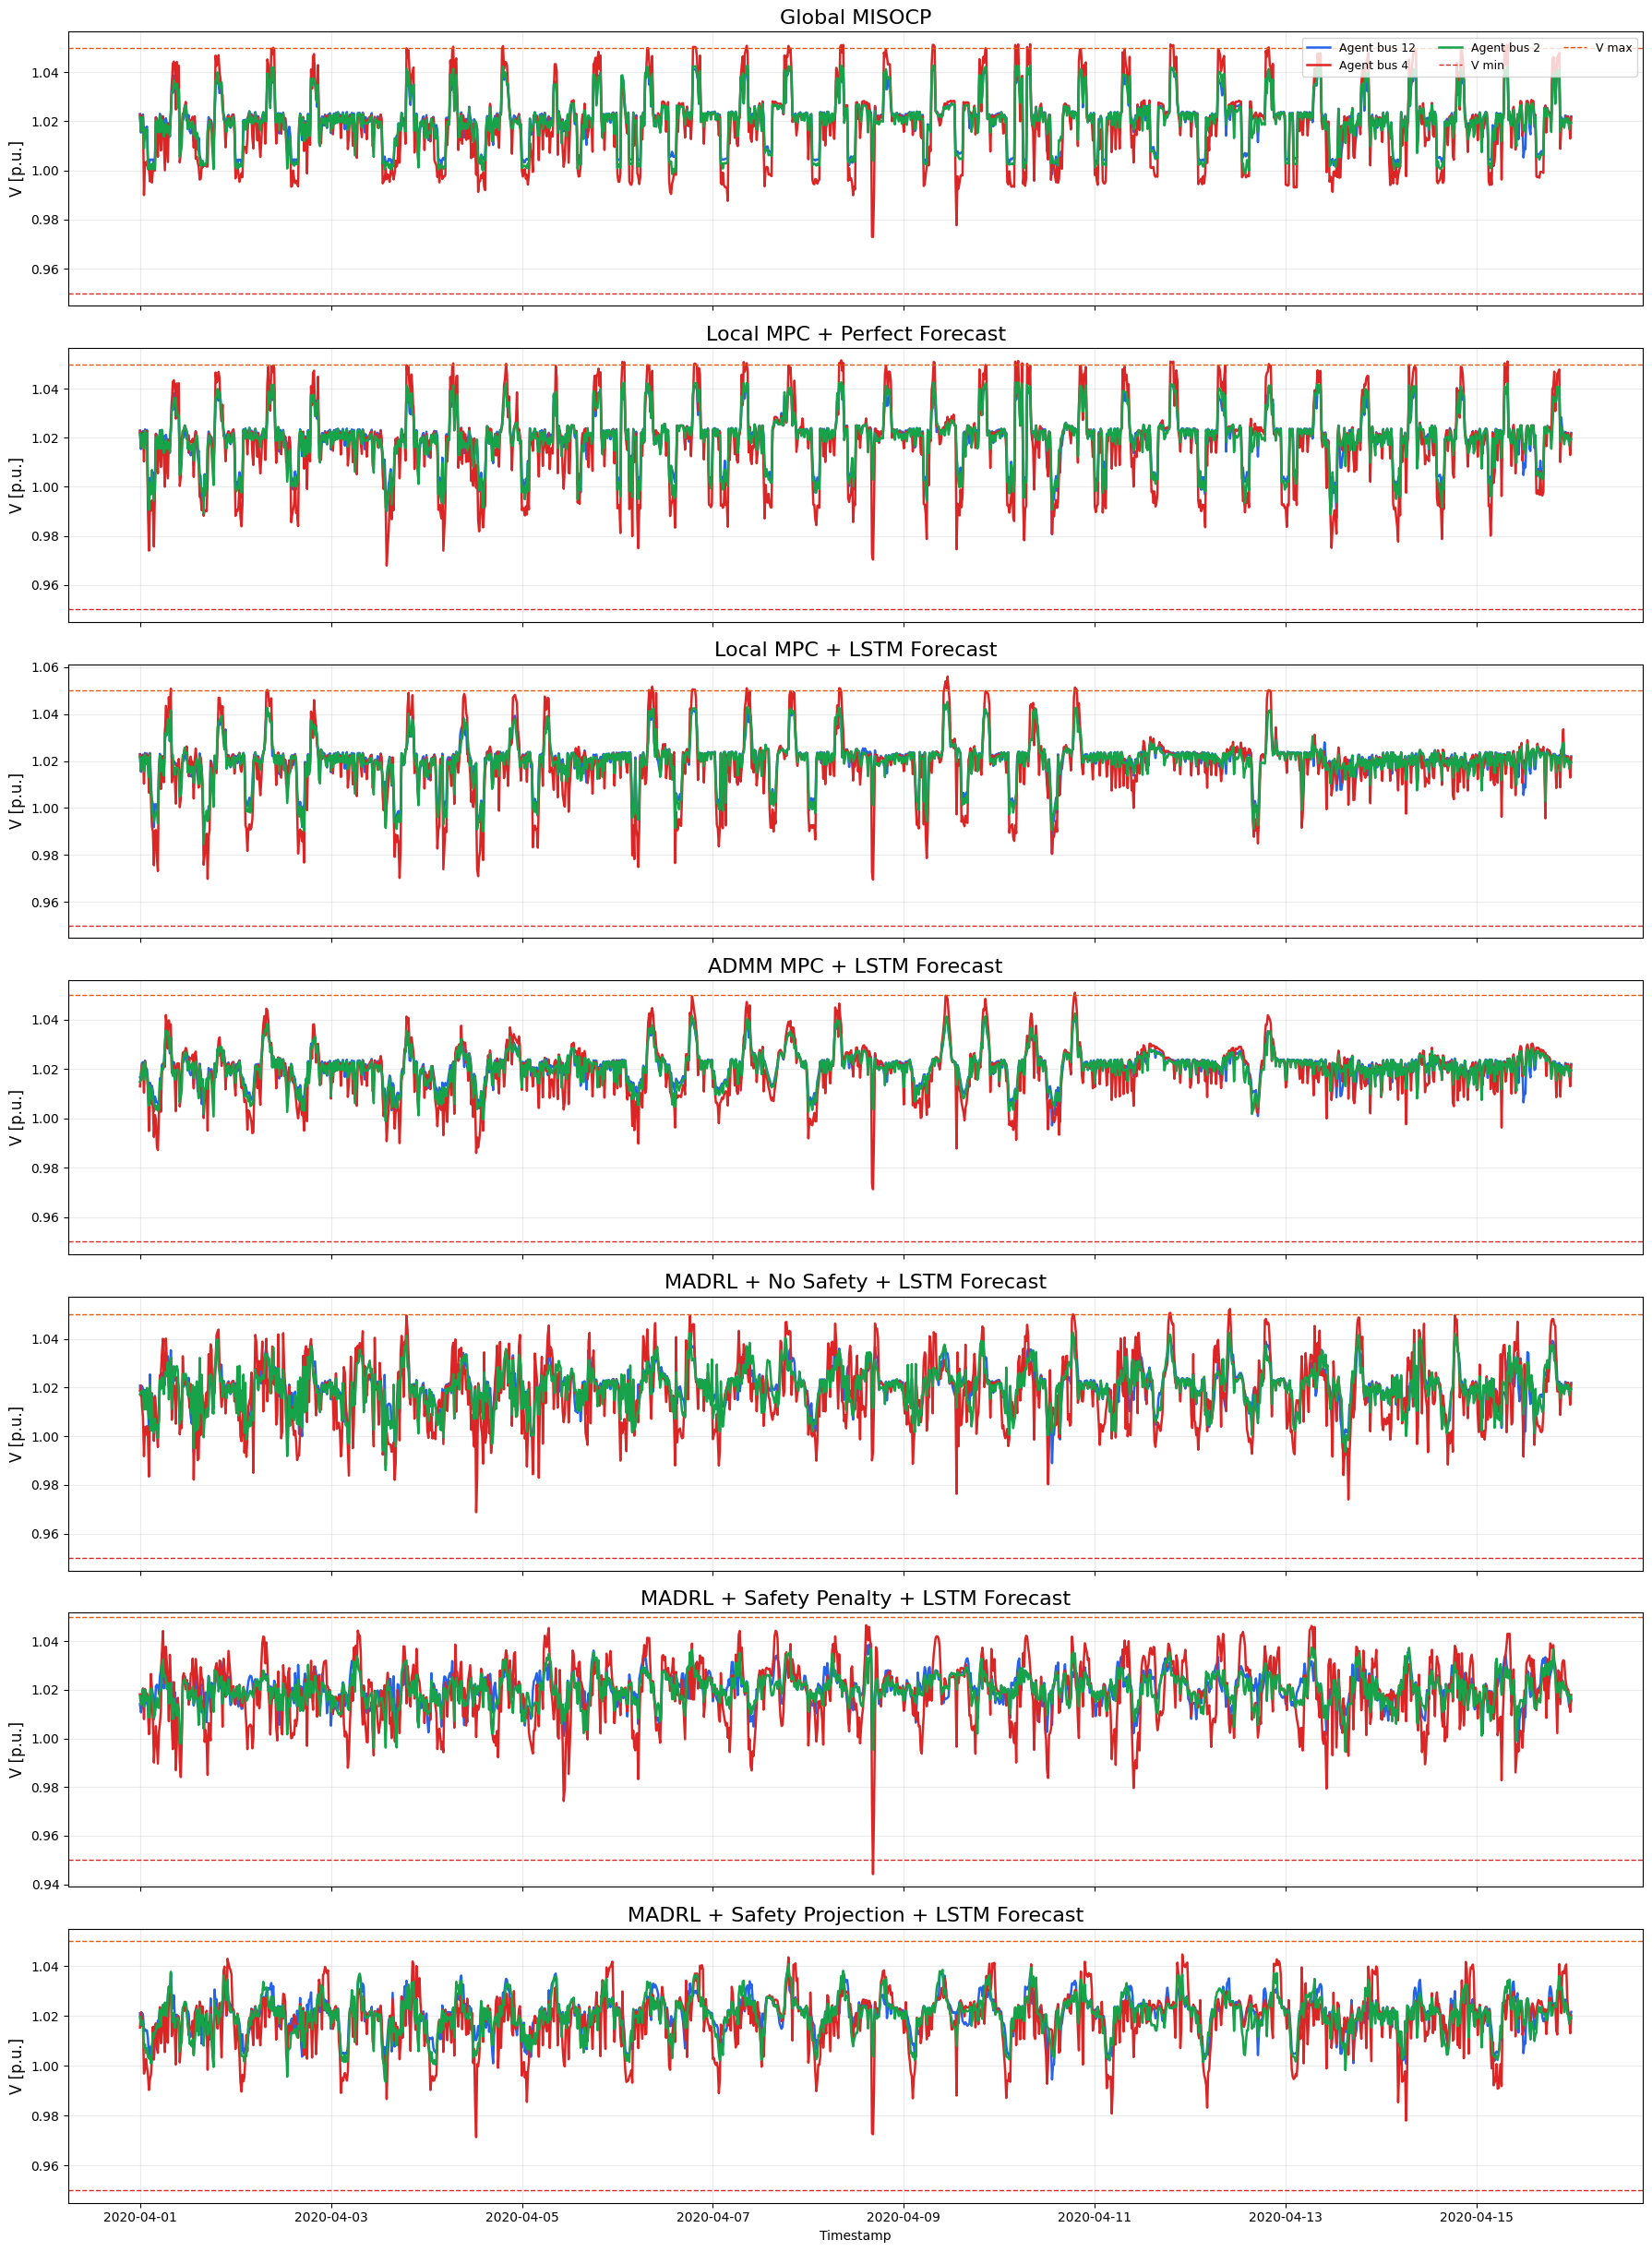

3. 净负荷


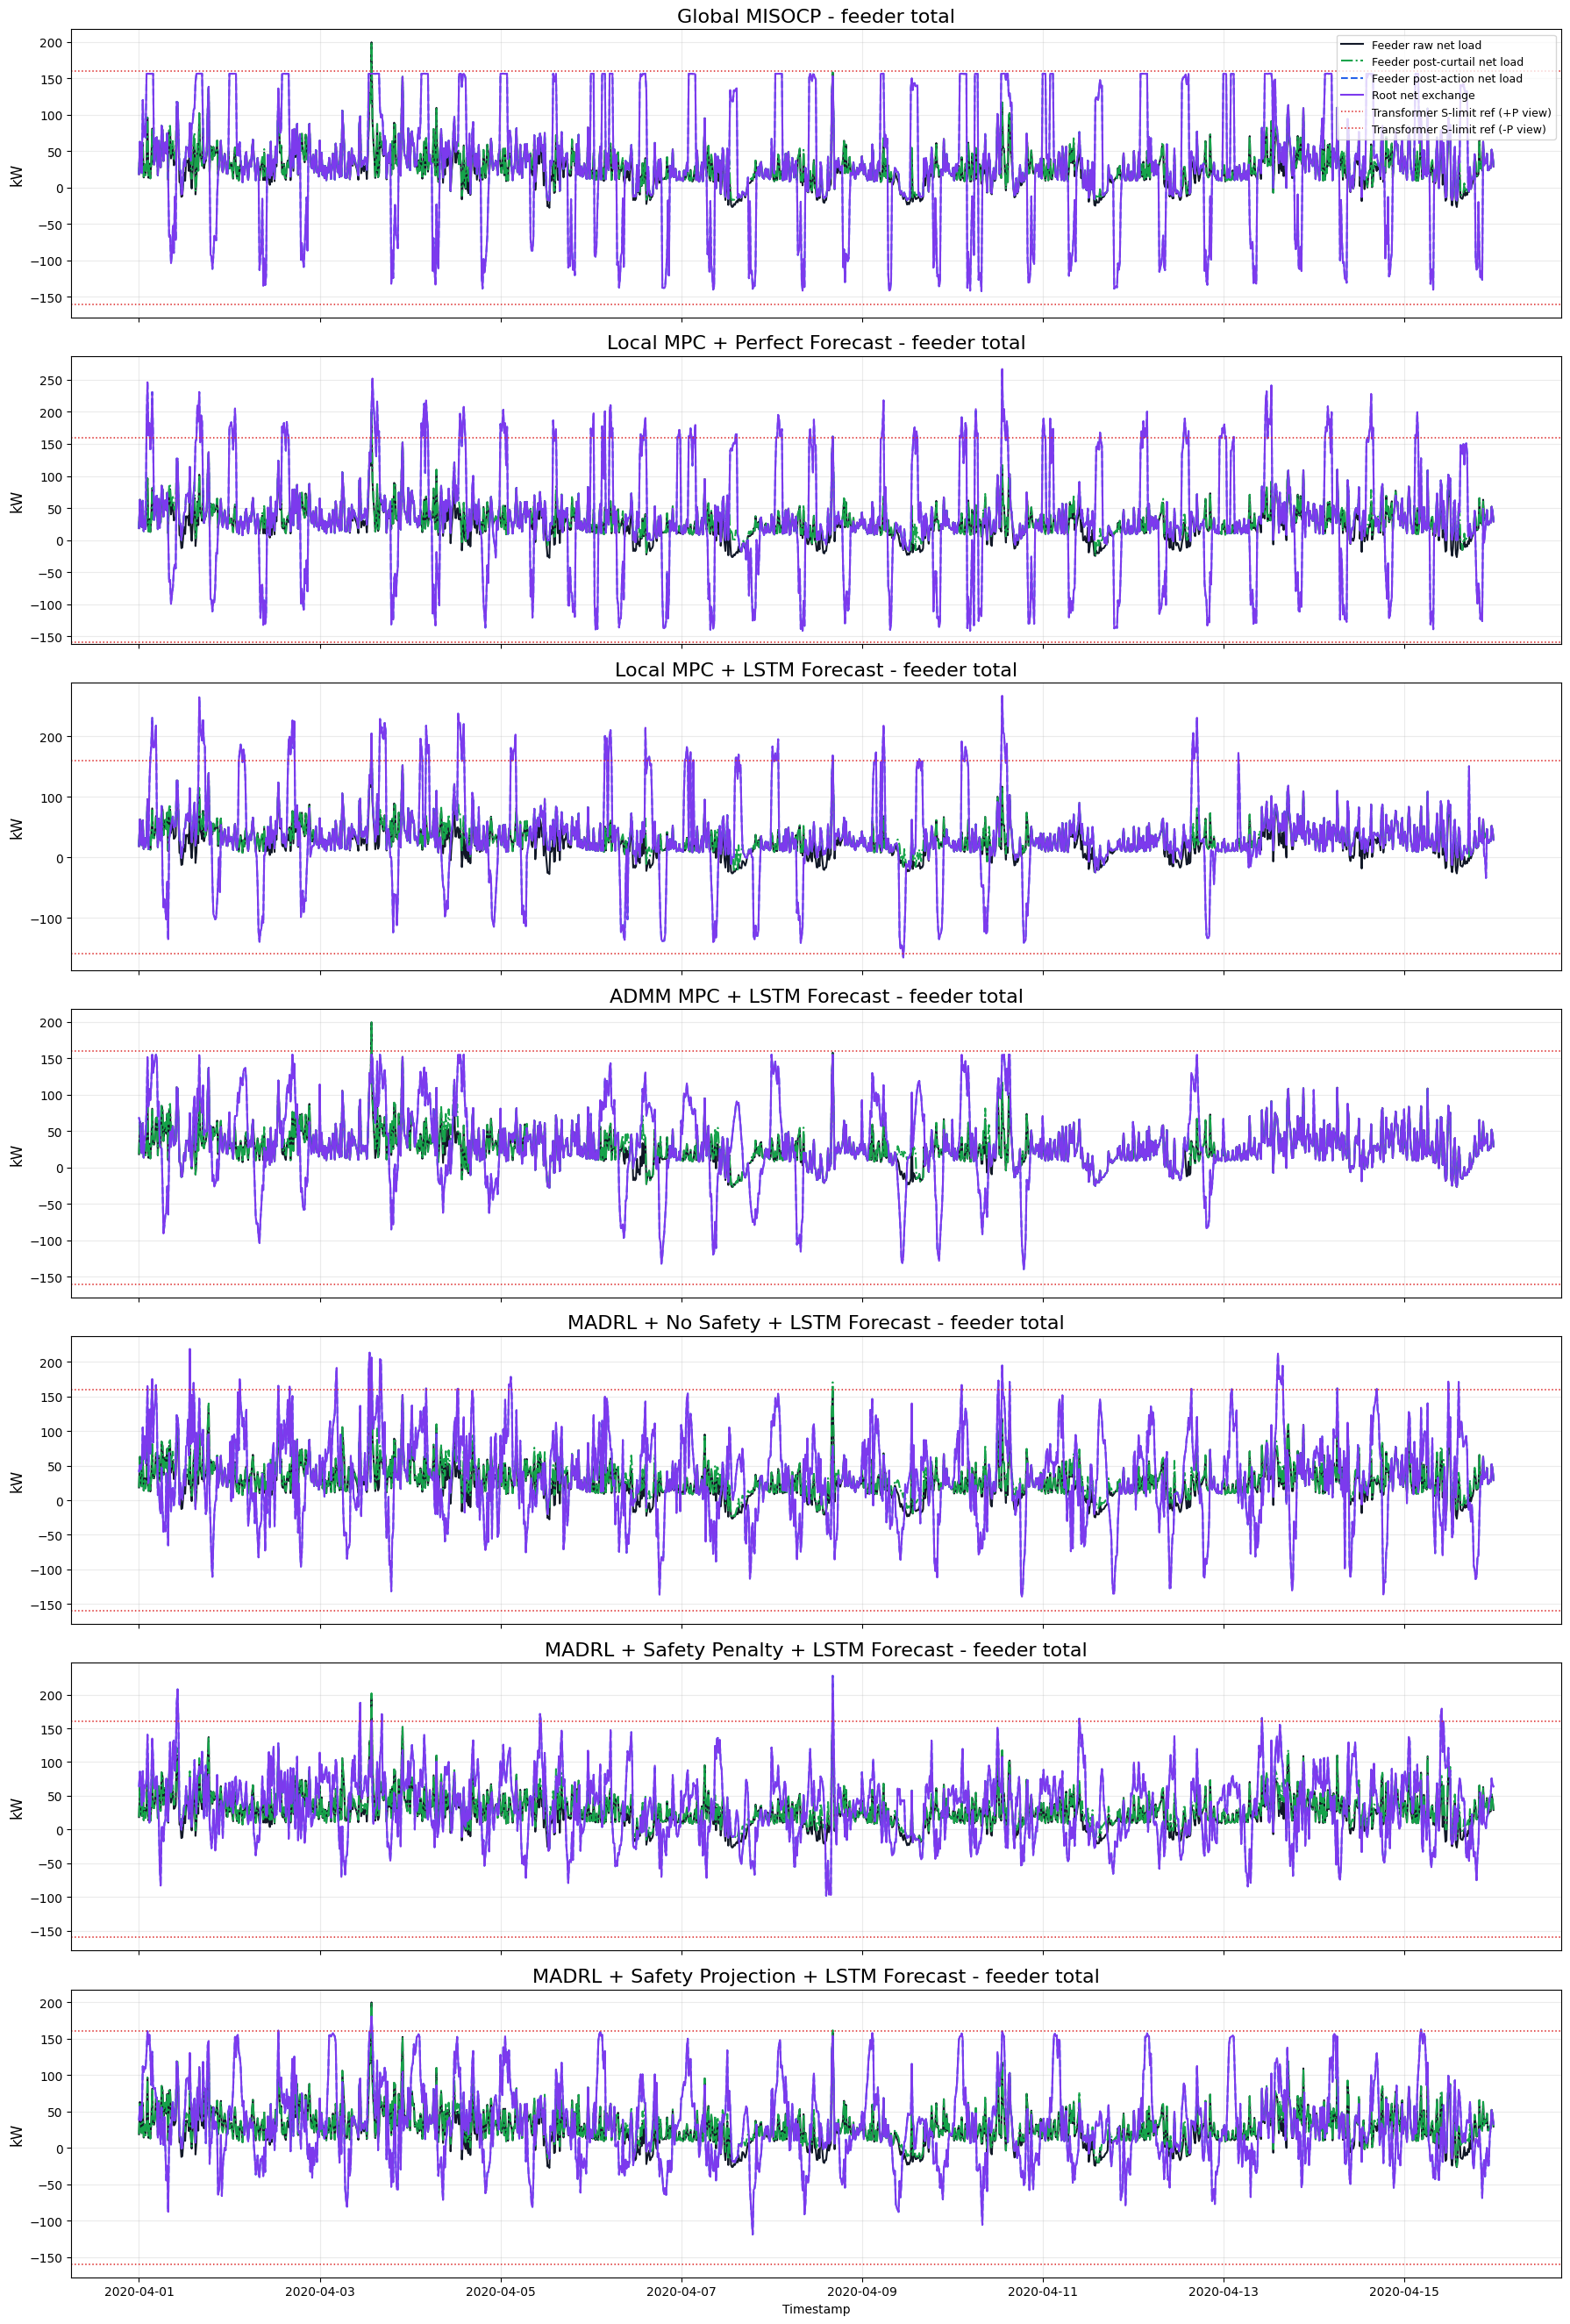

4. 总体储能充放功率与 SoC


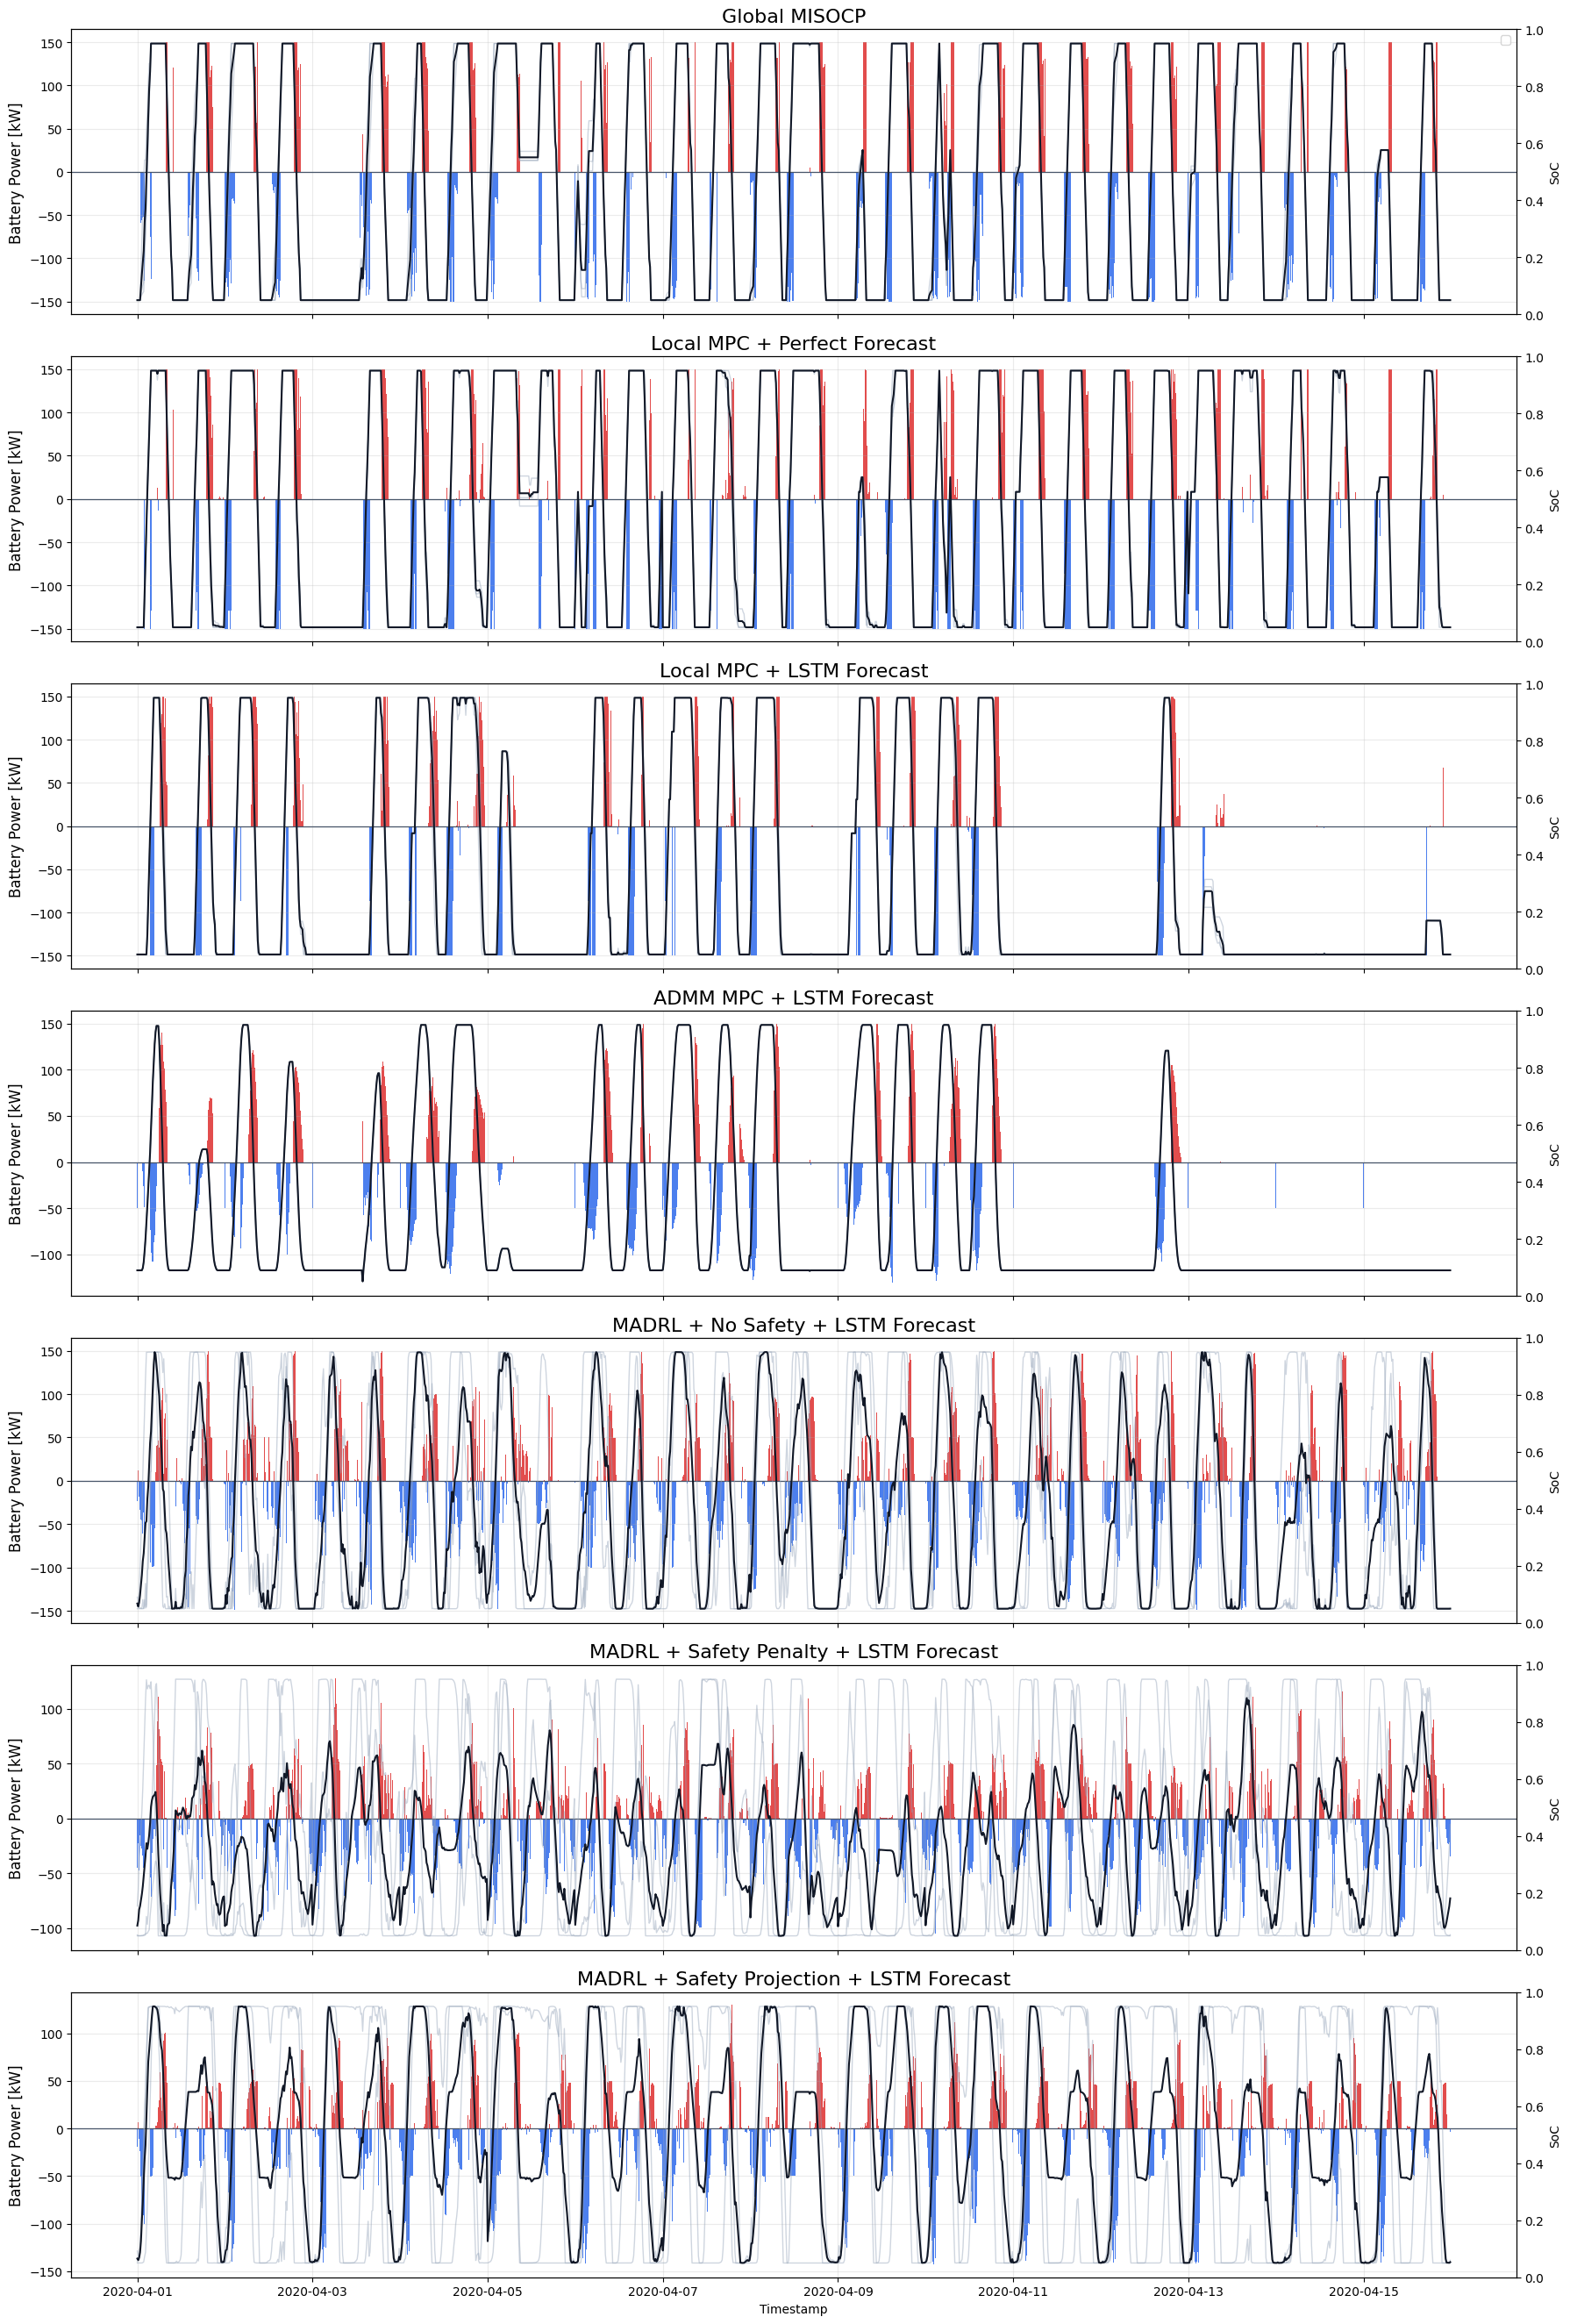

5. 电力电量平衡


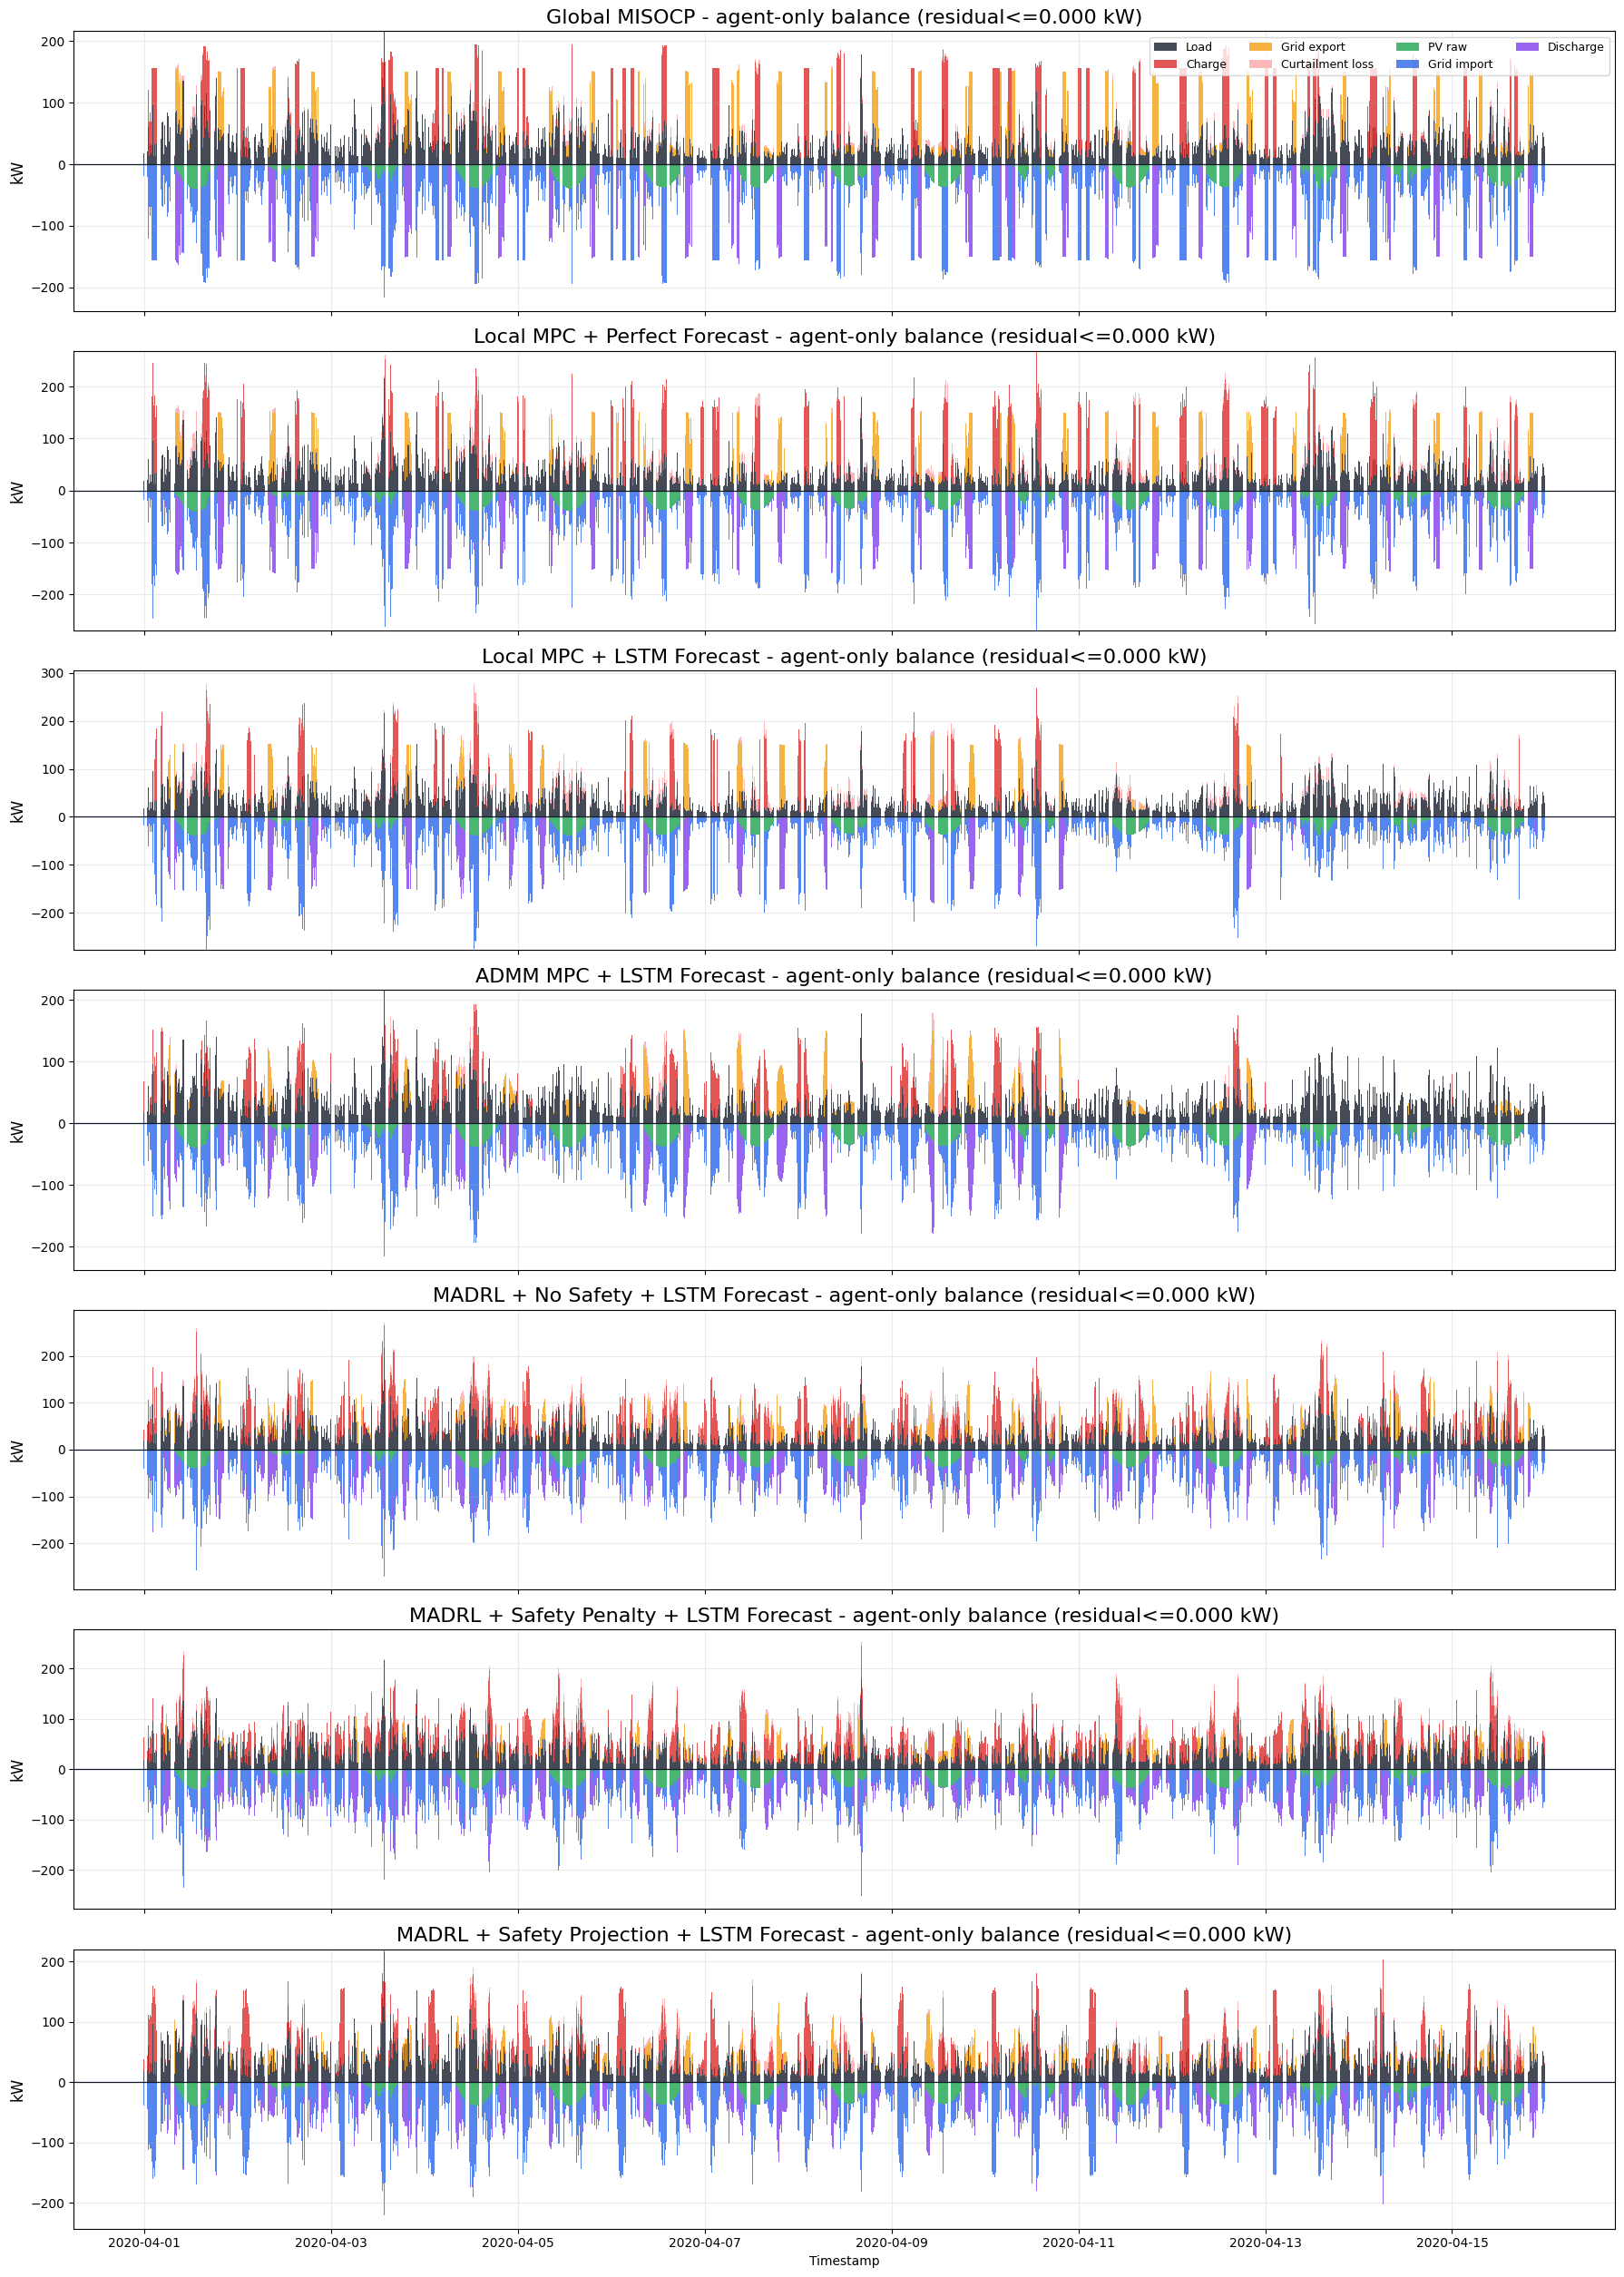

In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
from IPython.display import display

from scripts.compare import compare_records
from utils.run_artifacts import load_experiment_context

cfg, run_dir = load_experiment_context('artifacts/runs/20260504_234339_01e73bd1')
result = compare_records(cfg, run_dir)
display(result["metrics_df"])
display(result["economic_table"])
display(result["safety_table"])

_plot_specs = [
    ("1. 电价", "compare_price"),
    ("2. 电压", "compare_voltage"),
    ("3. 净负荷", "compare_net_load"),
    ("4. 总体储能充放功率与 SoC", "compare_battery_soc"),
    ("5. 电力电量平衡", "compare_power_balance"),
]
for title, name in _plot_specs:
    print(title)
    display(result["figures"][name])
    plt.close(result["figures"][name])
